# Modeling

**목표**: 5월 전력 소비 예측 모델 개발

**프로세스**:
1. 베이스라인 (비교 기준점)
2. Feature 선택 실험
3. Bayesian Optimization (Optuna)
4. 모델 비교 (LightGBM, XGBoost, CatBoost)
5. 최종 검증 & 시각화

**평가 지표**:
- 주요: 시간별 MAE (빠른 비교)
- 최종: MAE, RMSE, SMAPE, 누적 오차%

---

## 1. Setup

In [73]:
# Libraries
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge

# Tree Models
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# CatBoost 설치 및 import
try:
    from catboost import CatBoostRegressor
except ImportError:
    print("⚠️ CatBoost 설치 중...")
    !pip install catboost --break-system-packages -q
    from catboost import CatBoostRegressor

print("✅ Libraries loaded")

✅ Libraries loaded


In [35]:
# Optuna 설치
!pip install optuna --break-system-packages -q

import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

print("✅ Optuna installed")

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 4, in <module>
    from pip._internal.cli.main import main
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/build_env.py", line 19, in <module>
    from pip._internal.cli.spi

In [74]:
# Google Drive 연결
from google.colab import drive
drive.mount('/content/drive')

# 프로젝트 경로
PROJECT_PATH = '/content/drive/My Drive/Projects/smart-factory-power'
os.chdir(PROJECT_PATH)
print(f"✅ Working directory: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Working directory: /content/drive/My Drive/Projects/smart-factory-power


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


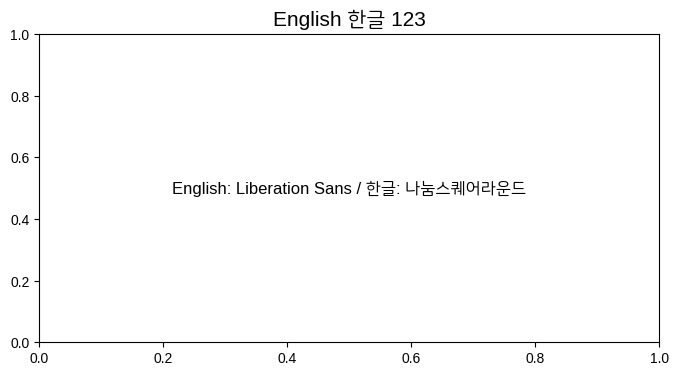

✅ 폰트 설정 완료!


In [37]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 1. 폰트 설치
!apt-get update -qq
!apt-get install -y fonts-nanum fonts-liberation -qq

# 2. matplotlib 캐시 삭제
!rm -rf ~/.cache/matplotlib/*

# 3. 폰트 경로 등록
font_dirs = ['/usr/share/fonts/truetype/nanum', '/usr/share/fonts/truetype/liberation']
font_files = fm.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    fm.fontManager.addfont(font_file)

# 4. 폰트 매니저 재로드 (설정 반영)
fm._load_fontmanager(try_read_cache=False)

# 5. 폰트 우선순위 설정
# 1순위: Liberation Sans
# 2순위: NanumSquareRound
plt.rcParams['font.family'] = ['Liberation Sans', 'NanumSquareRound']
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 6. 적용 확인
plt.figure(figsize=(8, 4))
plt.title("English 한글 123", fontsize=15)
plt.text(0.5, 0.5, "English: Liberation Sans / 한글: 나눔스퀘어라운드",
         ha='center', va='center', fontsize=12)
plt.show()

print("✅ 폰트 설정 완료!")

In [38]:
# 평가 함수 정의
def evaluate_model(y_true, y_pred, model_name='Model'):
    """
    모델 평가 함수

    Returns
    -------
    dict: MAE, RMSE, SMAPE, 누적오차%
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # SMAPE
    smape = 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

    # 누적 오차 (Bell-curve 대비)
    agg_true = y_true.sum()
    agg_pred = y_pred.sum()
    agg_error_pct = abs(agg_pred - agg_true) / agg_true * 100

    results = {
        'model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'SMAPE': smape,
        'Agg_Error_%': agg_error_pct
    }

    return results

def print_evaluation(results):
    """평가 결과 출력"""
    print(f"\n{'='*50}")
    print(f"📊 {results['model']} 평가 결과")
    print(f"{'='*50}")
    print(f"  MAE:           {results['MAE']:>8.2f} kW")
    print(f"  RMSE:          {results['RMSE']:>8.2f} kW")
    print(f"  SMAPE:         {results['SMAPE']:>8.2f} %")
    print(f"  누적 오차:      {results['Agg_Error_%']:>8.5f} %")

    if results['Agg_Error_%'] > 10:
        print(f"\n  ⚠️  경고: 누적 오차 10% 초과 (Bell-curve 점수 낮음)")
    elif results['Agg_Error_%'] > 5:
        print(f"\n  ⚡ 주의: 누적 오차 5% 초과")
    else:
        print(f"\n  ✅ 누적 오차 5% 이내 (양호)")

    print(f"{'='*50}\n")

print("✅ Evaluation functions defined")

✅ Evaluation functions defined


## 2. 데이터 로드

In [75]:
# Feature Engineering 결과 로드
print("📂 Loading featured data...")

train = pd.read_csv('data/processed/featured/full/train.csv')
test = pd.read_csv('data/processed/featured/full/test.csv')

# datetime 변환
train['datetime'] = pd.to_datetime(train['datetime'])
test['datetime'] = pd.to_datetime(test['datetime'])

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nTrain period: {train['datetime'].min()} ~ {train['datetime'].max()}")
print(f"Test period: {test['datetime'].min()} ~ {test['datetime'].max()}")

📂 Loading featured data...
Train shape: (2896, 48)
Test shape: (703, 48)

Train period: 2024-12-01 08:00:00 ~ 2025-03-31 23:00:00
Test period: 2025-04-01 00:00:00 ~ 2025-04-30 06:00:00


In [76]:
# Feature 그룹 로드
with open('data/processed/featured/full/feature_groups.json', 'r', encoding='utf-8') as f:
    feature_groups = json.load(f)

print("\n📊 Feature 그룹:")
for group_name, features in feature_groups.items():
    print(f"  {group_name:25s}: {len(features):2d}개")

# 전체 Feature 목록
all_features = []
for features in feature_groups.values():
    all_features.extend(features)

print(f"\n✅ 총 Feature 개수: {len(all_features)}개")


📊 Feature 그룹:
  time_cyclic              :  6개
  lag                      :  3개
  rolling_6h               :  4개
  rolling_12h              :  4개
  rolling_24h              :  4개
  diff                     :  2개

✅ 총 Feature 개수: 23개


In [77]:
# 타겟 변수 & Feature 분리
TARGET = 'activePower_mean'

# Train
X_train = train[all_features]
y_train = train[TARGET]

# Test (Validation용)
X_test = test[all_features]
y_test = test[TARGET]

print(f"\n📊 데이터 분리 완료:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")


📊 데이터 분리 완료:
  X_train: (2896, 23)
  y_train: (2896,)
  X_test:  (703, 23)
  y_test:  (703,)


In [78]:
# 결측치 처리 (Lag Features 초기값)
print("\n🔍 결측치 확인:")
print(f"Train 결측치: {X_train.isnull().sum().sum()}개")
print(f"Test 결측치:  {X_test.isnull().sum().sum()}개")

if X_train.isnull().sum().sum() > 0:
    print("\n⚠️ 결측치 처리 (Forward Fill)...")
    X_train = X_train.fillna(method='ffill').fillna(method='bfill')
    X_test = X_test.fillna(method='ffill').fillna(method='bfill')
    print("✅ 처리 완료")


🔍 결측치 확인:
Train 결측치: 12개
Test 결측치:  12개

⚠️ 결측치 처리 (Forward Fill)...
✅ 처리 완료


In [79]:
# Time Series Cross-Validation 설정
tscv = TimeSeriesSplit(n_splits=5)

print("\n📊 Time Series CV 설정:")
print(f"  Splits: {tscv.n_splits}")
print(f"\n  Fold 구조:")
for i, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    train_dates = train.iloc[train_idx]['datetime']
    val_dates = train.iloc[val_idx]['datetime']
    print(f"  Fold {i}: Train [{train_dates.min():%m/%d} ~ {train_dates.max():%m/%d}] "
          f"→ Val [{val_dates.min():%m/%d} ~ {val_dates.max():%m/%d}] "
          f"(Train: {len(train_idx):4d}, Val: {len(val_idx):3d})")


📊 Time Series CV 설정:
  Splits: 5

  Fold 구조:
  Fold 1: Train [12/01 ~ 12/21] → Val [12/21 ~ 01/10] (Train:  486, Val: 482)
  Fold 2: Train [12/01 ~ 01/10] → Val [01/10 ~ 01/30] (Train:  968, Val: 482)
  Fold 3: Train [12/01 ~ 01/30] → Val [01/30 ~ 02/19] (Train: 1450, Val: 482)
  Fold 4: Train [12/01 ~ 02/19] → Val [02/19 ~ 03/11] (Train: 1932, Val: 482)
  Fold 5: Train [12/01 ~ 03/11] → Val [03/11 ~ 03/31] (Train: 2414, Val: 482)


## 3. Phase 1: 베이스라인 모델

In [44]:
print("\n" + "="*60)
print("📍 Phase 1: 베이스라인 모델")
print("="*60)
print("\n목적: 비교 기준점 확보")
print("방법: 단순 평균 기반 예측\n")


📍 Phase 1: 베이스라인 모델

목적: 비교 기준점 확보
방법: 단순 평균 기반 예측



In [45]:
# 베이스라인 1: 전체 평균
baseline_1 = y_train.mean()
pred_baseline_1 = np.full(len(y_test), baseline_1)

results_baseline_1 = evaluate_model(y_test, pred_baseline_1, 'Baseline 1: 전체 평균')
print_evaluation(results_baseline_1)


📊 Baseline 1: 전체 평균 평가 결과
  MAE:              20.49 kW
  RMSE:             26.15 kW
  SMAPE:             0.68 %
  누적 오차:       0.02846 %

  ✅ 누적 오차 5% 이내 (양호)



In [46]:
# 베이스라인 2: 시간대별 평균
baseline_2 = train.groupby('hour')[TARGET].mean()
pred_baseline_2 = test['hour'].map(baseline_2).values

results_baseline_2 = evaluate_model(y_test, pred_baseline_2, 'Baseline 2: 시간대별 평균')
print_evaluation(results_baseline_2)


📊 Baseline 2: 시간대별 평균 평가 결과
  MAE:              20.55 kW
  RMSE:             26.27 kW
  SMAPE:             0.68 %
  누적 오차:       0.02827 %

  ✅ 누적 오차 5% 이내 (양호)



In [47]:
# 베이스라인 3: 요일×시간 평균
baseline_3 = train.groupby(['weekday', 'hour'])[TARGET].mean()
pred_baseline_3 = test.apply(
    lambda row: baseline_3.get((row['weekday'], row['hour']), baseline_1),
    axis=1
).values

results_baseline_3 = evaluate_model(y_test, pred_baseline_3, 'Baseline 3: 요일×시간 평균')
print_evaluation(results_baseline_3)


📊 Baseline 3: 요일×시간 평균 평가 결과
  MAE:              21.59 kW
  RMSE:             27.45 kW
  SMAPE:             0.72 %
  누적 오차:       0.02942 %

  ✅ 누적 오차 5% 이내 (양호)



In [48]:
# 베이스라인 결과 비교
baseline_results = pd.DataFrame([
    results_baseline_1,
    results_baseline_2,
    results_baseline_3
])

print("\n📊 베이스라인 모델 비교:")
print(baseline_results.to_string(index=False))

best_baseline = baseline_results.loc[baseline_results['MAE'].idxmin()]
print(f"\n✅ 최고 베이스라인: {best_baseline['model']}")
print(f"   MAE: {best_baseline['MAE']:.2f} kW")


📊 베이스라인 모델 비교:
               model       MAE      RMSE    SMAPE  Agg_Error_%
   Baseline 1: 전체 평균 20.488370 26.148930 0.680322     0.028462
 Baseline 2: 시간대별 평균 20.547465 26.265340 0.682286     0.028267
Baseline 3: 요일×시간 평균 21.590698 27.453463 0.716946     0.029419

✅ 최고 베이스라인: Baseline 1: 전체 평균
   MAE: 20.49 kW


## 4. Phase 2: Feature 선택 실험

In [49]:
print("\n" + "="*60)
print("📍 Phase 2: Feature 선택 실험")
print("="*60)
print("\n목적: 최적 Feature 조합 찾기")
print("방법: LightGBM Default 파라미터로 빠른 실험\n")


📍 Phase 2: Feature 선택 실험

목적: 최적 Feature 조합 찾기
방법: LightGBM Default 파라미터로 빠른 실험



In [50]:
# Feature 조합 정의
feature_combinations = {
    'v1_lag_only':
        feature_groups['lag'],

    'v2_lag+rolling6':
        feature_groups['lag'] + feature_groups['rolling_6h'],

    'v3_+diff':
        feature_groups['lag'] +
        feature_groups['rolling_6h'] +
        feature_groups['diff'],

    'v4_+all_rolling':
        feature_groups['lag'] +
        feature_groups['rolling_6h'] +
        feature_groups['rolling_12h'] +
        feature_groups['rolling_24h'] +
        feature_groups['diff'],

    'v5_all_features':
        all_features
}

print("📊 Feature 조합:")
for name, features in feature_combinations.items():
    print(f"  {name:20s}: {len(features):2d}개 Feature")

📊 Feature 조합:
  v1_lag_only         :  3개 Feature
  v2_lag+rolling6     :  7개 Feature
  v3_+diff            :  9개 Feature
  v4_+all_rolling     : 17개 Feature
  v5_all_features     : 23개 Feature


In [51]:
# Feature 선택 실험 (Time Series CV)
feature_results = []

print("\n🚀 Feature 선택 실험 시작...\n")

for exp_name, features in feature_combinations.items():
    print(f"\n{'='*50}")
    print(f"🔬 {exp_name} ({len(features)}개 Feature)")
    print(f"{'='*50}")

    # LightGBM Default
    model = LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        verbose=-1
    )

    # Time Series CV
    cv_scores = cross_val_score(
        model,
        X_train[features],
        y_train,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    cv_mae = -cv_scores.mean()
    cv_std = cv_scores.std()

    print(f"  CV MAE: {cv_mae:.2f} ± {cv_std:.2f} kW")

    # Test 데이터로 평가
    model.fit(X_train[features], y_train)
    y_pred_test = model.predict(X_test[features])
    test_results = evaluate_model(y_test, y_pred_test, exp_name)

    print(f"  Test MAE: {test_results['MAE']:.2f} kW")
    print(f"  누적 오차: {test_results['Agg_Error_%']:.2f}%")

    # 베이스라인 대비 개선율
    improvement = (best_baseline['MAE'] - test_results['MAE']) / best_baseline['MAE'] * 100
    print(f"  베이스라인 대비: {improvement:+.1f}%")

    feature_results.append({
        'experiment': exp_name,
        'n_features': len(features),
        'cv_mae': cv_mae,
        'test_mae': test_results['MAE'],
        'agg_error_%': test_results['Agg_Error_%'],
        'improvement_%': improvement
    })

print(f"\n{'='*50}")
print("✅ Feature 선택 실험 완료")
print(f"{'='*50}")


🚀 Feature 선택 실험 시작...


🔬 v1_lag_only (3개 Feature)
  CV MAE: 23.26 ± 0.30 kW
  Test MAE: 21.91 kW
  누적 오차: 0.04%
  베이스라인 대비: -6.9%

🔬 v2_lag+rolling6 (7개 Feature)
  CV MAE: 18.97 ± 1.24 kW
  Test MAE: 17.83 kW
  누적 오차: 0.01%
  베이스라인 대비: +13.0%

🔬 v3_+diff (9개 Feature)
  CV MAE: 2.85 ± 0.57 kW
  Test MAE: 2.05 kW
  누적 오차: 0.00%
  베이스라인 대비: +90.0%

🔬 v4_+all_rolling (17개 Feature)
  CV MAE: 3.01 ± 0.66 kW
  Test MAE: 2.10 kW
  누적 오차: 0.00%
  베이스라인 대비: +89.8%

🔬 v5_all_features (23개 Feature)
  CV MAE: 3.01 ± 0.67 kW
  Test MAE: 2.10 kW
  누적 오차: 0.00%
  베이스라인 대비: +89.7%

✅ Feature 선택 실험 완료


In [52]:
# 결과 비교
feature_results_df = pd.DataFrame(feature_results)

print("\n📊 Feature 선택 실험 결과:")
print(feature_results_df.to_string(index=False))

# 최적 조합
best_exp = feature_results_df.loc[feature_results_df['test_mae'].idxmin()]
print(f"\n✅ 최적 Feature 조합: {best_exp['experiment']}")
print(f"   Feature 개수: {int(best_exp['n_features'])}개")
print(f"   Test MAE: {best_exp['test_mae']:.2f} kW")
print(f"   베이스라인 대비 개선: {best_exp['improvement_%']:.1f}%")

# 최적 Feature 저장
best_features = feature_combinations[best_exp['experiment']]
print(f"\n→ 이후 실험에서 {len(best_features)}개 Feature 사용")


📊 Feature 선택 실험 결과:
     experiment  n_features    cv_mae  test_mae  agg_error_%  improvement_%
    v1_lag_only           3 23.256319 21.909400     0.035509      -6.935789
v2_lag+rolling6           7 18.969851 17.826176     0.005449      12.993684
       v3_+diff           9  2.852077  2.047406     0.004024      90.006985
v4_+all_rolling          17  3.006407  2.098545     0.000106      89.757384
v5_all_features          23  3.008203  2.101906     0.001576      89.740982

✅ 최적 Feature 조합: v3_+diff
   Feature 개수: 9개
   Test MAE: 2.05 kW
   베이스라인 대비 개선: 90.0%

→ 이후 실험에서 9개 Feature 사용



📊 Feature Importance 분석 (default)...

Top 10 Important Features:
                         feature  importance
        activePower_mean_diff_2h         562
         activePower_mean_lag_2h         549
        activePower_mean_diff_1h         474
         activePower_mean_lag_1h         445
 activePower_mean_rolling_max_6h         252
 activePower_mean_rolling_min_6h         224
activePower_mean_rolling_mean_6h         209
 activePower_mean_rolling_std_6h         174
         activePower_mean_lag_3h         111


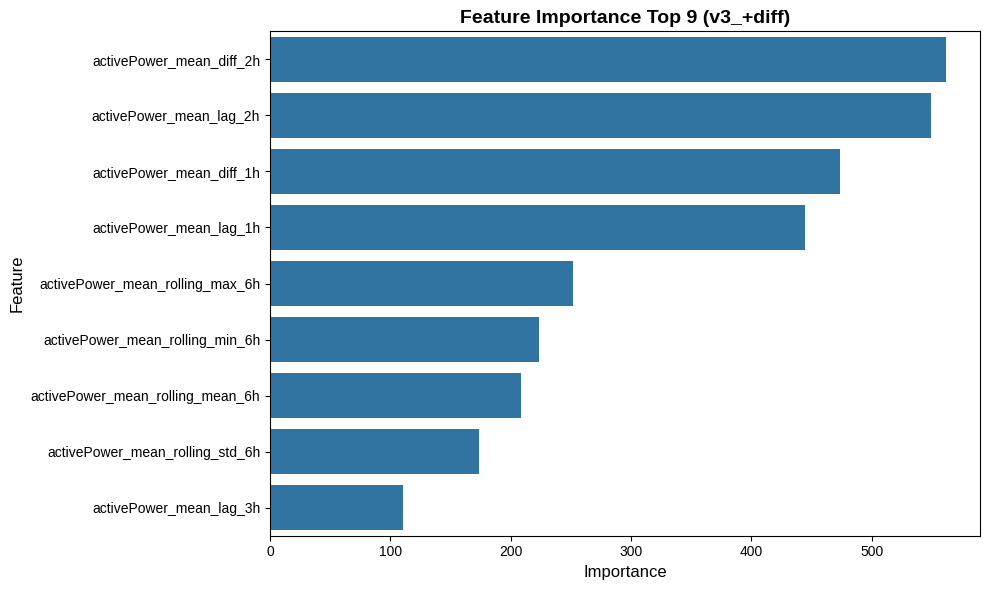


✅ Feature Importance 저장: results/figures/feature_importance.png


In [53]:
# Feature Importance 분석
print("\n📊 Feature Importance 분석 (default)...")

model_best = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
model_best.fit(X_train[best_features], y_train)

# Feature Importance 추출
feature_importance = pd.DataFrame({
    'feature': best_features,
    'importance': model_best.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10).to_string(index=False))

# 시각화
plt.figure(figsize=(10, 6))
top_n = min(20, len(feature_importance))
sns.barplot(data=feature_importance.head(top_n), y='feature', x='importance')
plt.title(f'Feature Importance Top {top_n} ({best_exp["experiment"]})', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('results/figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Feature Importance 저장: results/figures/feature_importance.png")

In [54]:
print("\n📊 전체 Feature Importance:")
print(feature_importance.to_string(index=False))

print("\n📊 중요도 통계:")
print(f"Total Importance: {feature_importance['importance'].sum():.0f}")
print(f"Top 1 비율: {feature_importance.head(1)['importance'].sum() / feature_importance['importance'].sum() * 100:.1f}%")
print(f"Top 2 비율: {feature_importance.head(2)['importance'].sum() / feature_importance['importance'].sum() * 100:.1f}%")
print(f"Top 3 비율: {feature_importance.head(3)['importance'].sum() / feature_importance['importance'].sum() * 100:.1f}%")
print(f"Top 4 비율: {feature_importance.head(4)['importance'].sum() / feature_importance['importance'].sum() * 100:.1f}%")
print(f"Top 5 비율: {feature_importance.head(5)['importance'].sum() / feature_importance['importance'].sum() * 100:.1f}%")
print(f"Top 6비율: {feature_importance.head(6)['importance'].sum() / feature_importance['importance'].sum() * 100:.1f}%")
print(f"Top 7 비율: {feature_importance.head(7)['importance'].sum() / feature_importance['importance'].sum() * 100:.1f}%")
print(f"Top 8 비율: {feature_importance.head(8)['importance'].sum() / feature_importance['importance'].sum() * 100:.1f}%")
print(f"Top 9 비율: {feature_importance.head(9)['importance'].sum() / feature_importance['importance'].sum() * 100:.1f}%")


📊 전체 Feature Importance:
                         feature  importance
        activePower_mean_diff_2h         562
         activePower_mean_lag_2h         549
        activePower_mean_diff_1h         474
         activePower_mean_lag_1h         445
 activePower_mean_rolling_max_6h         252
 activePower_mean_rolling_min_6h         224
activePower_mean_rolling_mean_6h         209
 activePower_mean_rolling_std_6h         174
         activePower_mean_lag_3h         111

📊 중요도 통계:
Total Importance: 3000
Top 1 비율: 18.7%
Top 2 비율: 37.0%
Top 3 비율: 52.8%
Top 4 비율: 67.7%
Top 5 비율: 76.1%
Top 6비율: 83.5%
Top 7 비율: 90.5%
Top 8 비율: 96.3%
Top 9 비율: 100.0%


In [55]:
# Best Features 재 정의 및 평가

exp_name =  '피처 7개'
best_features = [
    'activePower_mean_diff_2h', 'activePower_mean_lag_2h',
    'activePower_mean_diff_1h', 'activePower_mean_lag_1h',
    'activePower_mean_rolling_max_6h', 'activePower_mean_rolling_min_6h',
    'activePower_mean_rolling_mean_6h'
]
print(f"\n{'='*50}")
print(f"🔬 {exp_name} ({len(best_features)}개 Feature)")
print(f"{'='*50}")
# LightGBM Default
model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)

# Time Series CV
cv_scores = cross_val_score(
    model,
    X_train[best_features],
    y_train,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

cv_mae = -cv_scores.mean()
cv_std = cv_scores.std()

print(f"  CV MAE: {cv_mae:.2f} ± {cv_std:.2f} kW")

# Test 데이터로 평가
model.fit(X_train[best_features], y_train)
y_pred_test = model.predict(X_test[best_features])
test_results = evaluate_model(y_test, y_pred_test, exp_name)

print(f"  Test MAE: {test_results['MAE']:.2f} kW")
print(f"  누적 오차: {test_results['Agg_Error_%']:.2f}%")

# 베이스라인 대비 개선율
improvement = (best_baseline['MAE'] - test_results['MAE']) / best_baseline['MAE'] * 100
print(f"  베이스라인 대비: {improvement:+.1f}%")

feature_results.append({
    'experiment': exp_name,
    'n_features': len(best_features),
    'cv_mae': cv_mae,
    'test_mae': test_results['MAE'],
    'agg_error_%': test_results['Agg_Error_%'],
    'improvement_%': improvement
})

print(f"\n{'='*50}")
print("✅ Feature 선택 실험 완료")
print(f"{'='*50}")


🔬 피처 7개 (7개 Feature)
  CV MAE: 2.76 ± 0.58 kW
  Test MAE: 2.06 kW
  누적 오차: 0.00%
  베이스라인 대비: +90.0%

✅ Feature 선택 실험 완료


## 5. Phase 3: Bayesian Optimization (Optuna)

In [56]:
print("\n" + "="*60)
print("📍 Phase 3: Bayesian Optimization (Optuna)")
print("="*60)
print("\n목적: LightGBM 하이퍼파라미터 최적화")
print("방법: Optuna로 100회 시도\n")


📍 Phase 3: Bayesian Optimization (Optuna)

목적: LightGBM 하이퍼파라미터 최적화
방법: Optuna로 100회 시도



In [57]:
# Optuna Objective Function
def objective(trial):
    """
    Optuna objective function for LightGBM
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbose': -1
    }

    # Time Series CV
    model = LGBMRegressor(**params)
    cv_scores = cross_val_score(
        model,
        X_train[best_features],
        y_train,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    mae = -cv_scores.mean()

    return mae

print("✅ Objective function defined")

✅ Objective function defined


In [58]:
# Optuna Study 실행
print("\n🚀 Optuna 최적화 시작...")
print("   (100회 시도, 약 10-20분 소요)\n")

study = optuna.create_study(direction='minimize', study_name='LightGBM_Optimization')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("\n✅ Optuna 최적화 완료!")

[I 2026-02-08 13:34:32,729] A new study created in memory with name: LightGBM_Optimization



🚀 Optuna 최적화 시작...
   (100회 시도, 약 10-20분 소요)



  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-08 13:34:36,688] Trial 0 finished with value: 2.4686339227181557 and parameters: {'n_estimators': 773, 'learning_rate': 0.015867069271883888, 'max_depth': 5, 'num_leaves': 126, 'min_child_samples': 17, 'subsample': 0.6746522333376241, 'colsample_bytree': 0.7291341504510429, 'reg_alpha': 4.8565531400879225, 'reg_lambda': 0.0048093767844642026}. Best is trial 0 with value: 2.4686339227181557.
[I 2026-02-08 13:34:39,061] Trial 1 finished with value: 2.8955551040570557 and parameters: {'n_estimators': 715, 'learning_rate': 0.01599187642566924, 'max_depth': 6, 'num_leaves': 95, 'min_child_samples': 52, 'subsample': 0.6728320123801567, 'colsample_bytree': 0.7155817135845399, 'reg_alpha': 1.2849788911073514, 'reg_lambda': 1.1833894764442594}. Best is trial 0 with value: 2.4686339227181557.
[I 2026-02-08 13:34:40,316] Trial 2 finished with value: 3.2121216285269605 and parameters: {'n_estimators': 540, 'learning_rate': 0.19187390040537375, 'max_depth': 5, 'num_leaves': 26, 'min_chil

In [59]:
# 최적 파라미터
best_params = study.best_params
best_mae = study.best_value

print("\n" + "="*50)
print("🏆 최적 하이퍼파라미터")
print("="*50)
print(f"\nBest CV MAE: {best_mae:.2f} kW\n")
print("Best Parameters:")
for param, value in best_params.items():
    if isinstance(value, float):
        print(f"  {param:20s}: {value:.6f}")
    else:
        print(f"  {param:20s}: {value}")

# Default 대비 개선
default_mae = feature_results_df.loc[
    feature_results_df['experiment'] == best_exp['experiment'], 'cv_mae'
].values[0]
improvement = (default_mae - best_mae) / default_mae * 100
print(f"\n📊 Default 대비 개선: {improvement:+.2f}%")



🏆 최적 하이퍼파라미터

Best CV MAE: 2.07 kW

Best Parameters:
  n_estimators        : 915
  learning_rate       : 0.081722
  max_depth           : 3
  num_leaves          : 30
  min_child_samples   : 9
  subsample           : 0.579316
  colsample_bytree    : 0.658555
  reg_alpha           : 0.138699
  reg_lambda          : 0.000671

📊 Default 대비 개선: +27.27%


In [60]:
# Optuna 시각화
print("\n📊 Optuna 시각화...")

# 1. Optimization History
fig1 = plot_optimization_history(study)
fig1.update_layout(title='Optimization History', width=800, height=500)
fig1.show()

# 2. Parameter Importance
fig2 = plot_param_importances(study)
fig2.update_layout(title='Hyperparameter Importance', width=800, height=500)
fig2.show()

print("\n✅ Optuna 시각화 완료")


📊 Optuna 시각화...



✅ Optuna 시각화 완료


In [61]:
# 최적 모델로 Test 평가
print("\n📊 최적 모델 Test 평가...")

best_params['random_state'] = 42
best_params['verbose'] = -1

model_optimized = LGBMRegressor(**best_params)
model_optimized.fit(X_train[best_features], y_train)

y_pred_optimized = model_optimized.predict(X_test[best_features])
results_optimized = evaluate_model(y_test, y_pred_optimized, 'LightGBM (Optimized)')
print_evaluation(results_optimized)


📊 최적 모델 Test 평가...

📊 LightGBM (Optimized) 평가 결과
  MAE:               1.51 kW
  RMSE:              2.46 kW
  SMAPE:             0.05 %
  누적 오차:       0.00070 %

  ✅ 누적 오차 5% 이내 (양호)



In [62]:
# ================================
# CatBoost Hyperparameter Tuning with Optuna
# ================================

# Optuna Objective Function for CatBoost
def objective_catboost(trial):
    """
    Optuna objective function for CatBoost
    """
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_seed': 42,
        'verbose': False
    }

    # Time Series CV
    model = CatBoostRegressor(**params)
    cv_scores = cross_val_score(
        model,
        X_train[best_features],
        y_train,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    mae = -cv_scores.mean()

    return mae

print("✅ CatBoost Objective function defined")

# Optuna Study 실행
print("\n🚀 CatBoost Optuna 최적화 시작...")
print("   (100회 시도, 약 10-20분 소요)\n")

study_catboost = optuna.create_study(direction='minimize', study_name='CatBoost_Optimization')
study_catboost.optimize(objective_catboost, n_trials=100, show_progress_bar=True)

print("\n✅ CatBoost Optuna 최적화 완료!")

# 최적 파라미터
best_params_catboost = study_catboost.best_params
best_mae_catboost = study_catboost.best_value

print("\n" + "="*50)
print("🏆 CatBoost 최적 하이퍼파라미터")
print("="*50)
print(f"\nBest CV MAE: {best_mae_catboost:.2f} kW\n")
print("Best Parameters:")
for param, value in best_params_catboost.items():
    if isinstance(value, float):
        print(f"  {param:20s}: {value:.6f}")
    else:
        print(f"  {param:20s}: {value}")

# Default 대비 개선
default_mae = feature_results_df.loc[
    feature_results_df['experiment'] == best_exp['experiment'], 'cv_mae'
].values[0]
improvement_catboost = (default_mae - best_mae_catboost) / default_mae * 100
print(f"\n📊 Default 대비 개선: {improvement_catboost:+.2f}%")

# 최적 모델로 Test 평가
print("\n📊 CatBoost 최적 모델 Test 평가...")

best_params_catboost['random_seed'] = 42
best_params_catboost['verbose'] = False

model_catboost_optimized = CatBoostRegressor(**best_params_catboost)
model_catboost_optimized.fit(X_train[best_features], y_train)

y_pred_catboost_optimized = model_catboost_optimized.predict(X_test[best_features])
results_catboost_optimized = evaluate_model(y_test, y_pred_catboost_optimized, 'CatBoost (Optimized)')
print_evaluation(results_catboost_optimized)

[I 2026-02-08 13:38:12,261] A new study created in memory with name: CatBoost_Optimization


✅ CatBoost Objective function defined

🚀 CatBoost Optuna 최적화 시작...
   (100회 시도, 약 10-20분 소요)



  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-08 13:39:06,255] Trial 0 finished with value: 2.806643508326449 and parameters: {'iterations': 708, 'learning_rate': 0.22448802659168657, 'depth': 9, 'l2_leaf_reg': 1.4569714273233305e-05, 'border_count': 252, 'random_strength': 0.666432001279651, 'bagging_temperature': 0.8150257216443605}. Best is trial 0 with value: 2.806643508326449.
[I 2026-02-08 13:39:48,495] Trial 1 finished with value: 3.321864358606814 and parameters: {'iterations': 889, 'learning_rate': 0.22637813883181565, 'depth': 9, 'l2_leaf_reg': 0.012596897572385931, 'border_count': 143, 'random_strength': 7.84429622912581, 'bagging_temperature': 0.3480127109067014}. Best is trial 0 with value: 2.806643508326449.
[I 2026-02-08 13:40:17,982] Trial 2 finished with value: 1.9744854417536004 and parameters: {'iterations': 695, 'learning_rate': 0.10355021580227786, 'depth': 8, 'l2_leaf_reg': 7.30638024757767e-08, 'border_count': 250, 'random_strength': 0.2208311537539276, 'bagging_temperature': 0.8937121231012843}. 

In [63]:
# ================================
# XGBoost Hyperparameter Tuning with Optuna
# ================================

# Optuna Objective Function for XGBoost
def objective_xgboost(trial):
    """
    Optuna objective function for XGBoost
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbosity': 0
    }

    # Time Series CV
    model = XGBRegressor(**params)
    cv_scores = cross_val_score(
        model,
        X_train[best_features],
        y_train,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    mae = -cv_scores.mean()

    return mae

print("✅ XGBoost Objective function defined")

# Optuna Study 실행
print("\n🚀 XGBoost Optuna 최적화 시작...")
print("   (100회 시도, 약 10-20분 소요)\n")

study_xgboost = optuna.create_study(direction='minimize', study_name='XGBoost_Optimization')
study_xgboost.optimize(objective_xgboost, n_trials=100, show_progress_bar=True)

print("\n✅ XGBoost Optuna 최적화 완료!")

# 최적 파라미터
best_params_xgboost = study_xgboost.best_params
best_mae_xgboost = study_xgboost.best_value

print("\n" + "="*50)
print("🏆 XGBoost 최적 하이퍼파라미터")
print("="*50)
print(f"\nBest CV MAE: {best_mae_xgboost:.2f} kW\n")
print("Best Parameters:")
for param, value in best_params_xgboost.items():
    if isinstance(value, float):
        print(f"  {param:20s}: {value:.6f}")
    else:
        print(f"  {param:20s}: {value}")

# Default 대비 개선
default_mae = feature_results_df.loc[
    feature_results_df['experiment'] == best_exp['experiment'], 'cv_mae'
].values[0]
improvement_xgboost = (default_mae - best_mae_xgboost) / default_mae * 100
print(f"\n📊 Default 대비 개선: {improvement_xgboost:+.2f}%")

# 최적 모델로 Test 평가
print("\n📊 XGBoost 최적 모델 Test 평가...")

best_params_xgboost['random_state'] = 42
best_params_xgboost['verbosity'] = 0

model_xgboost_optimized = XGBRegressor(**best_params_xgboost)
model_xgboost_optimized.fit(X_train[best_features], y_train)

y_pred_xgboost_optimized = model_xgboost_optimized.predict(X_test[best_features])
results_xgboost_optimized = evaluate_model(y_test, y_pred_xgboost_optimized, 'XGBoost (Optimized)')
print_evaluation(results_xgboost_optimized)

[I 2026-02-08 13:57:05,516] A new study created in memory with name: XGBoost_Optimization


✅ XGBoost Objective function defined

🚀 XGBoost Optuna 최적화 시작...
   (100회 시도, 약 10-20분 소요)



  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-08 13:57:07,143] Trial 0 finished with value: 2.6110447958988936 and parameters: {'n_estimators': 216, 'learning_rate': 0.04637987290912244, 'max_depth': 7, 'min_child_weight': 6, 'subsample': 0.7066416732697376, 'colsample_bytree': 0.7985817661602642, 'gamma': 2.347083820938469, 'reg_alpha': 9.938277364578765e-07, 'reg_lambda': 0.009940551352984934}. Best is trial 0 with value: 2.6110447958988936.
[I 2026-02-08 13:57:08,316] Trial 1 finished with value: 4.325295766068032 and parameters: {'n_estimators': 980, 'learning_rate': 0.15520763950779648, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.7160609636021122, 'colsample_bytree': 0.5250620327697798, 'gamma': 2.313668587405048, 'reg_alpha': 0.00017488067836362271, 'reg_lambda': 0.0020323413579529073}. Best is trial 0 with value: 2.6110447958988936.
[I 2026-02-08 13:57:10,210] Trial 2 finished with value: 4.111723522864795 and parameters: {'n_estimators': 516, 'learning_rate': 0.01853679347045975, 'max_depth': 4, 'min_c

## 6. Phase 4: 모델 비교


🏆 MODEL PERFORMANCE COMPARISON
   Model  Best CV MAE  Test MAE  Test RMSE  Test SMAPE  Agg Error (%)  Improvement (%)  Rank (CV MAE)  Rank (Test MAE)
LightGBM     2.074192  1.505331   2.464278    0.049976       0.000703        27.274356              3                3
CatBoost     1.376277  0.930855   2.232386    0.030916       0.003510        51.744744              1                1
 XGBoost     1.871807  1.457708   2.421809    0.048420       0.001531        34.370407              2                2

🥇 Best Model: CatBoost
   └─ Test MAE: 0.9309 kW
   └─ CV MAE: 1.3763 kW
   └─ Test RMSE: 2.2324 kW
   └─ Agg Error: 0.0035%
   └─ Improvement: +51.74%


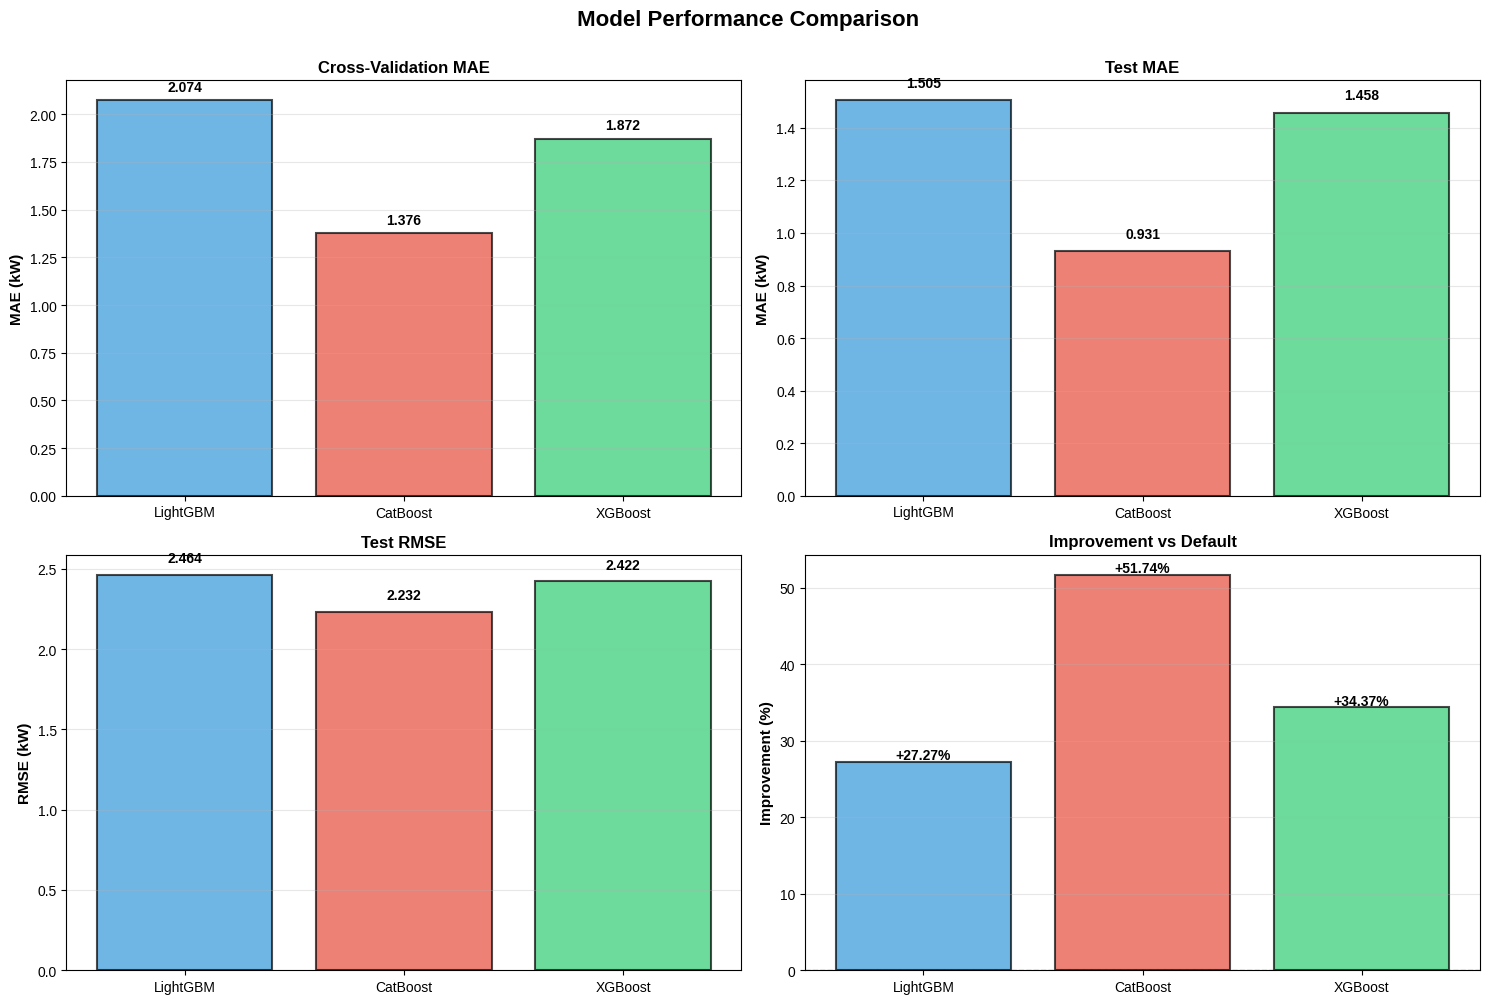


✅ All models optimized and ready for deployment!
   Models stored in 'final_models' dictionary

📊 FINAL MODEL RANKINGS (by Test MAE)
         Model  Test MAE  Test RMSE  Agg Error (%)
Rank                                              
1     CatBoost  0.930855   2.232386       0.003510
2      XGBoost  1.457708   2.421809       0.001531
3     LightGBM  1.505331   2.464278       0.000703

💾 To use best model:
   best_model = final_models['CatBoost']
   predictions = best_model.predict(X_test[best_features])


In [80]:
# ================================
# Model Performance Comparison
# ================================

# 성능 비교 데이터프레임 생성
comparison_results = pd.DataFrame({
    'Model': ['LightGBM', 'CatBoost', 'XGBoost'],
    'Best CV MAE': [
        best_mae,
        best_mae_catboost,
        best_mae_xgboost
    ],
    'Test MAE': [
        results_optimized['MAE'],
        results_catboost_optimized['MAE'],
        results_xgboost_optimized['MAE']
    ],
    'Test RMSE': [
        results_optimized['RMSE'],
        results_catboost_optimized['RMSE'],
        results_xgboost_optimized['RMSE']
    ],
    'Test SMAPE': [
        results_optimized['SMAPE'],
        results_catboost_optimized['SMAPE'],
        results_xgboost_optimized['SMAPE']
    ],
    'Agg Error (%)': [
        results_optimized['Agg_Error_%'],
        results_catboost_optimized['Agg_Error_%'],
        results_xgboost_optimized['Agg_Error_%']
    ],
    'Improvement (%)': [
        improvement,
        improvement_catboost,
        improvement_xgboost
    ]
})

# 성능 순위 추가
comparison_results['Rank (CV MAE)'] = comparison_results['Best CV MAE'].rank().astype(int)
comparison_results['Rank (Test MAE)'] = comparison_results['Test MAE'].rank().astype(int)

print("\n" + "="*80)
print("🏆 MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_results.to_string(index=False))
print("="*80)

# 최고 성능 모델 선정
best_model_idx = comparison_results['Test MAE'].idxmin()
best_model_name = comparison_results.loc[best_model_idx, 'Model']
best_test_mae = comparison_results.loc[best_model_idx, 'Test MAE']

print(f"\n🥇 Best Model: {best_model_name}")
print(f"   └─ Test MAE: {best_test_mae:.4f} kW")
print(f"   └─ CV MAE: {comparison_results.loc[best_model_idx, 'Best CV MAE']:.4f} kW")
print(f"   └─ Test RMSE: {comparison_results.loc[best_model_idx, 'Test RMSE']:.4f} kW")
print(f"   └─ Agg Error: {comparison_results.loc[best_model_idx, 'Agg Error (%)']:.4f}%")
print(f"   └─ Improvement: {comparison_results.loc[best_model_idx, 'Improvement (%)']:+.2f}%")

# 시각화: 모델 성능 비교
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(' Model Performance Comparison', fontsize=16, fontweight='bold', y=1.00)

colors = ['#3498db', '#e74c3c', '#2ecc71']

# 1. CV MAE 비교
axes[0, 0].bar(comparison_results['Model'], comparison_results['Best CV MAE'],
               color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0, 0].set_ylabel('MAE (kW)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Cross-Validation MAE', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_results['Best CV MAE']):
    axes[0, 0].text(i, v + 0.05, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)

# 2. Test MAE 비교
axes[0, 1].bar(comparison_results['Model'], comparison_results['Test MAE'],
               color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('MAE (kW)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Test MAE', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_results['Test MAE']):
    axes[0, 1].text(i, v + 0.05, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)

# 3. Test RMSE 비교
axes[1, 0].bar(comparison_results['Model'], comparison_results['Test RMSE'],
               color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('RMSE (kW)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Test RMSE', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_results['Test RMSE']):
    axes[1, 0].text(i, v + 0.08, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)

# 4. Improvement 비교
axes[1, 1].bar(comparison_results['Model'], comparison_results['Improvement (%)'],
               color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylabel('Improvement (%)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Improvement vs Default', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
for i, v in enumerate(comparison_results['Improvement (%)']):
    axes[1, 1].text(i, v + 0.3, f'{v:+.2f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# 최종 모델 딕셔너리
final_models = {
    'LightGBM': model_optimized,
    'CatBoost': model_catboost_optimized,
    'XGBoost': model_xgboost_optimized
}

# 최종 결과 요약
print(f"\n✅ All models optimized and ready for deployment!")
print(f"   Models stored in 'final_models' dictionary\n")

print("="*60)
print("📊 FINAL MODEL RANKINGS (by Test MAE)")
print("="*60)
ranking = comparison_results.sort_values('Test MAE')[['Model', 'Test MAE', 'Test RMSE', 'Agg Error (%)']].reset_index(drop=True)
ranking.index = ranking.index + 1
ranking.index.name = 'Rank'
print(ranking.to_string())
print("="*60)

print(f"\n💾 To use best model:")
print(f"   best_model = final_models['{best_model_name}']")
print(f"   predictions = best_model.predict(X_test[best_features])")

## 7. Phase 5: 최종 검증 & 시각화

In [65]:
print("\n" + "="*60)
print("📍 Phase 5: 최종 검증 & 시각화")
print("="*60)
print("\n목적: 최종 모델 성능 분석 및 제출 파일 생성\n")


📍 Phase 5: 최종 검증 & 시각화

목적: 최종 모델 성능 분석 및 제출 파일 생성



In [81]:
# 최종 모델 설정
final_model = model_catboost_optimized
final_model_name = 'CatBoost'

# 최종 예측
y_pred_final = final_model.predict(X_test[best_features])

# 최종 평가
final_results = evaluate_model(y_test, y_pred_final, f'{final_model_name} (Final)')
print_evaluation(final_results)


📊 CatBoost (Final) 평가 결과
  MAE:               0.93 kW
  RMSE:              2.23 kW
  SMAPE:             0.03 %
  누적 오차:       0.00351 %

  ✅ 누적 오차 5% 이내 (양호)



In [67]:
# 베이스라인 대비 개선율
print("\n📊 베이스라인 대비 개선:")
improvement_vs_baseline = (
    (best_baseline['MAE'] - final_results['MAE']) / best_baseline['MAE'] * 100
)
print(f"  베이스라인 MAE: {best_baseline['MAE']:.2f} kW")
print(f"  최종 모델 MAE:  {final_results['MAE']:.2f} kW")
print(f"  개선율:         {improvement_vs_baseline:+.1f}%")


📊 베이스라인 대비 개선:
  베이스라인 MAE: 20.49 kW
  최종 모델 MAE:  0.93 kW
  개선율:         +95.5%


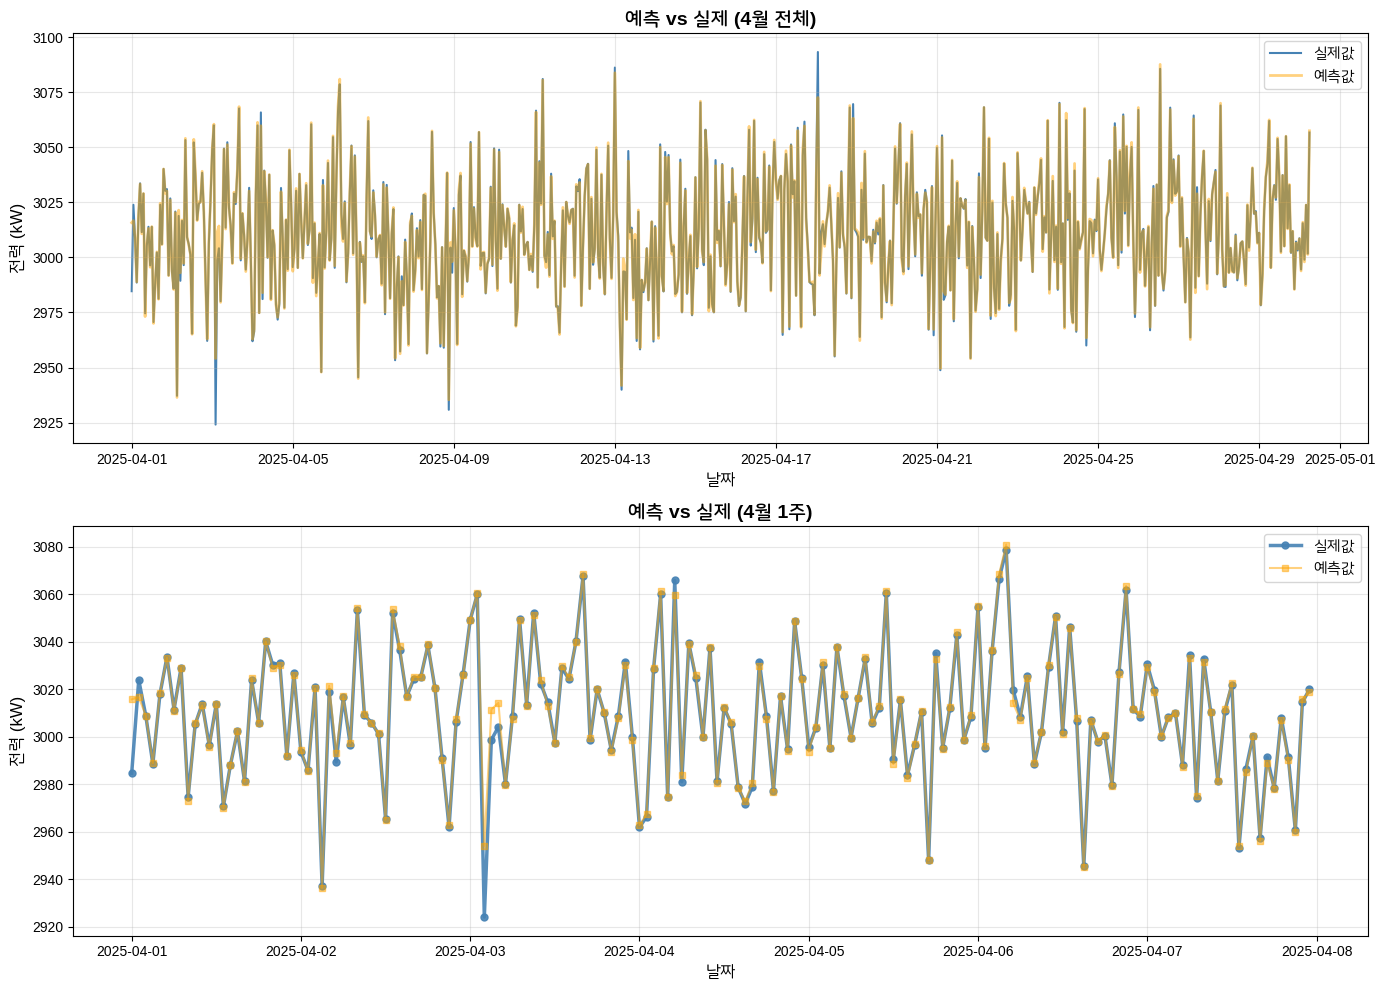

✅ 저장: results/figures/final_prediction.png


In [68]:
# 시각화 1: 예측 vs 실제
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 전체 기간
axes[0].plot(test['datetime'], y_test, label='실제값',
             linewidth=1.5, alpha=1, color='steelblue', zorder=1)
axes[0].plot(test['datetime'], y_pred_final, label='예측값',
             linewidth=2, alpha=0.5, color='orange', zorder=2)
axes[0].set_xlabel('날짜', fontsize=12)
axes[0].set_ylabel('전력 (kW)', fontsize=12)
axes[0].set_title('예측 vs 실제 (4월 전체)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# 일주일 확대
week_mask = (test['datetime'] >= '2025-04-01') & (test['datetime'] < '2025-04-08')
axes[1].plot(test.loc[week_mask, 'datetime'], y_test[week_mask],
             label='실제값', linewidth=2.5, alpha=0.9,
             marker='o', markersize=5, color='steelblue')
axes[1].plot(test.loc[week_mask, 'datetime'], y_pred_final[week_mask],
             label='예측값', linewidth=1.5, alpha=0.5,
             marker='s', markersize=4, color='orange')
axes[1].set_xlabel('날짜', fontsize=12)
axes[1].set_ylabel('전력 (kW)', fontsize=12)
axes[1].set_title('예측 vs 실제 (4월 1주)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/final_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 저장: results/figures/final_prediction.png")

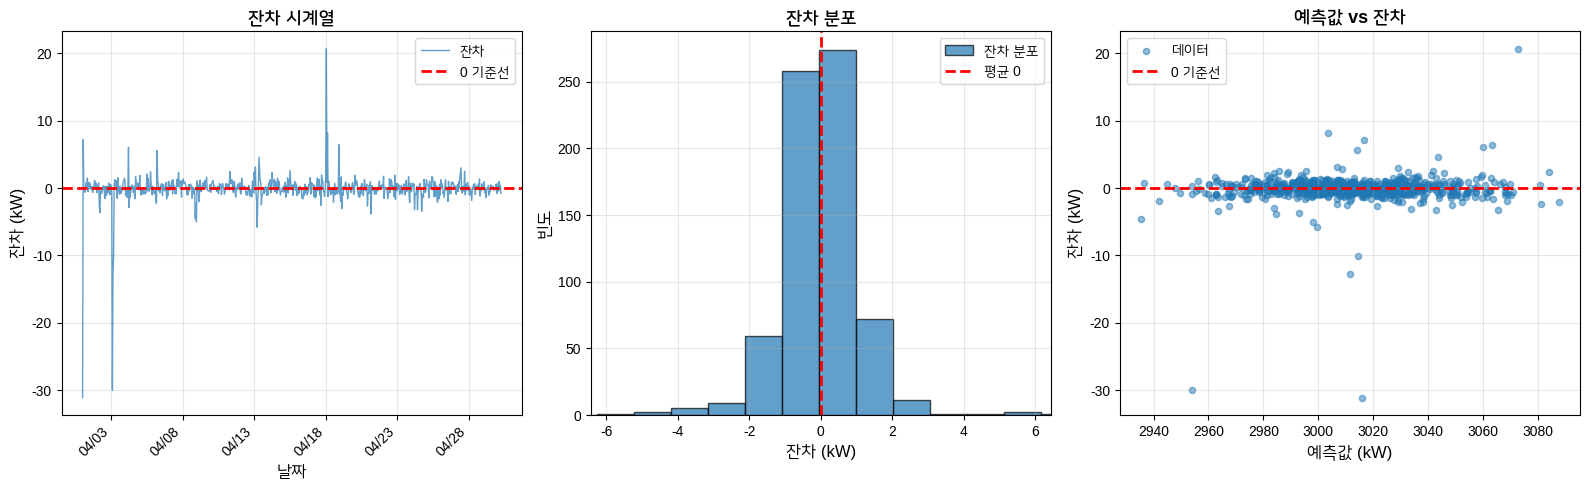

✅ 저장: results/figures/residual_analysis.png


In [69]:
# 시각화 2: 잔차 분석
residuals = y_test - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 잔차 시계열
axes[0].plot(test['datetime'], residuals, linewidth=1, alpha=0.7, label='잔차')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2, label='0 기준선')
axes[0].set_xlabel('날짜', fontsize=12)
axes[0].set_ylabel('잔차 (kW)', fontsize=12)
axes[0].set_title('잔차 시계열', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=10)

# x축 날짜 포맷 설정
import matplotlib.dates as mdates
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 잔차 분포
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, label='잔차 분포')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='평균 0')
axes[1].set_xlabel('잔차 (kW)', fontsize=12)
axes[1].set_ylabel('빈도', fontsize=12)
axes[1].set_title('잔차 분포', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=10)
percentile_99 = np.percentile(np.abs(residuals), 99)
axes[1].set_xlim(-percentile_99, percentile_99)


# 예측값 vs 잔차
axes[2].scatter(y_pred_final, residuals, alpha=0.5, s=20, label='데이터')
axes[2].axhline(y=0, color='r', linestyle='--', linewidth=2, label='0 기준선')
axes[2].set_xlabel('예측값 (kW)', fontsize=12)
axes[2].set_ylabel('잔차 (kW)', fontsize=12)
axes[2].set_title('예측값 vs 잔차', fontsize=13, fontweight='bold')
axes[2].grid(alpha=0.3)
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.savefig('results/figures/residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 저장: results/figures/residual_analysis.png")

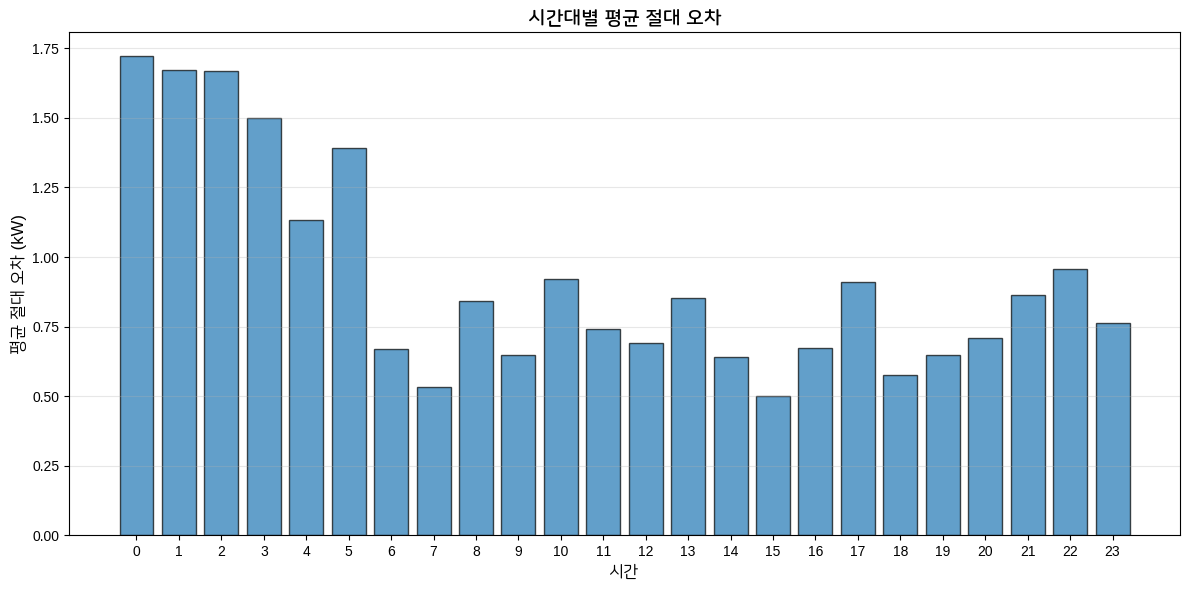

✅ 저장: results/figures/hourly_error.png

📊 오차가 큰 시간대 Top 5:
hour
0    1.721113
1    1.671781
2    1.666890
3    1.499271
5    1.393382
Name: error, dtype: float64


In [70]:
# 시각화 3: 시간대별 오차 분석
test_with_pred = test.copy()
test_with_pred['prediction'] = y_pred_final
test_with_pred['error'] = np.abs(y_test - y_pred_final)

hourly_error = test_with_pred.groupby('hour')['error'].mean()

plt.figure(figsize=(12, 6))
plt.bar(hourly_error.index, hourly_error.values, edgecolor='black', alpha=0.7)
plt.xlabel('시간', fontsize=12)
plt.ylabel('평균 절대 오차 (kW)', fontsize=12)
plt.title('시간대별 평균 절대 오차', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/hourly_error.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 저장: results/figures/hourly_error.png")

# 오차가 큰 시간대
print("\n📊 오차가 큰 시간대 Top 5:")
print(hourly_error.sort_values(ascending=False).head())

## 8. 5월 전력 소비 예측 및 제출 파일 생성

In [83]:
# ============================================
# 1. 최적 피처 & 하이퍼파라미터 확인
# ============================================
print("\n📍 Phase 6: 최종 모델 학습 및 5월 예측")
print(f"✅ Features: {len(best_features)}개")
print(f"✅ Best Params: {best_params_catboost}")

# ============================================
# 2. 전체 데이터 결합 (12월~4월)
# ============================================
print("\n📊 Train + Test 데이터 결합 (12월~4월 전체)...")

# Train(12월~3월) + Test(4월) 결합
full_data = pd.concat([train, test], axis=0, ignore_index=True)
full_data = full_data.sort_values('datetime').reset_index(drop=True)

print(f"  전체 데이터: {full_data.shape}")
print(f"  기간: {full_data['datetime'].min()} ~ {full_data['datetime'].max()}")

# Feature & Target 분리
X_full = full_data[best_features]
y_full = full_data[TARGET]

print(f"  X_full: {X_full.shape}")
print(f"  y_full: {y_full.shape}")

# ============================================
# 3. 최종 모델 학습 (12월~4월 전체 데이터)
# ============================================
print("\n🚀 최종 모델 학습 중...")

# 위에서 정의한 best_params 사용
final_model = CatBoostRegressor(**best_params_catboost)
final_model.fit(X_full, y_full)

print("✅ 학습 완료!")

# ============================================
# 4. 5월 예측용 데이터 생성
# ============================================
print("\n📅 5월 예측 데이터 생성 중...")

# 5월 시간 생성 (2025-05-01 00:00:00 ~ 2025-05-28 23:00:00)
may_dates = pd.date_range(start='2025-05-01 00:00:00',
                          end='2025-05-28 23:00:00',
                          freq='H')

print(f"  5월 시간: {len(may_dates)}개 (예상: 672시간)")

# 5월 예측용 DataFrame 생성
may_data = pd.DataFrame({'datetime': may_dates})

# Feature 생성을 위한 기본 컬럼 추가
may_data['activePower_mean'] = np.nan

# 전체 데이터에 5월 추가 (Feature 생성용)
combined = pd.concat([full_data[['datetime', 'activePower_mean']], may_data],
                     axis=0, ignore_index=True)
combined = combined.sort_values('datetime').reset_index(drop=True)

print(f"  결합 데이터: {combined.shape}")

# ============================================
# 5. 5월 Feature 생성 (Autoregressive 방식)
# ============================================
print("\n🔧 5월 Feature 생성 (Autoregressive)...")

# Lag feature 생성을 위한 예측값 저장 리스트
predictions = []

for idx in range(len(may_dates)):
    current_idx = len(full_data) + idx

    # Lag features 계산
    if current_idx >= 1:
        lag_1h = combined.loc[current_idx - 1, 'activePower_mean']
    else:
        lag_1h = full_data['activePower_mean'].iloc[-1]

    if current_idx >= 2:
        lag_2h = combined.loc[current_idx - 2, 'activePower_mean']
    else:
        lag_2h = full_data['activePower_mean'].iloc[-2]

    # Diff features
    diff_1h = lag_1h - lag_2h if current_idx >= 2 else 0

    if current_idx >= 3:
        lag_3h = combined.loc[current_idx - 3, 'activePower_mean']
        diff_2h = lag_2h - lag_3h
    else:
        diff_2h = 0

    # Rolling features (6h)
    if current_idx >= 6:
        recent_6h = [combined.loc[current_idx - i, 'activePower_mean']
                     for i in range(1, 7)]
        rolling_mean_6h = np.mean(recent_6h)
        rolling_max_6h = np.max(recent_6h)
        rolling_min_6h = np.min(recent_6h)
    else:
        # 데이터 부족 시 마지막 6시간 데이터 사용
        recent_6h = full_data['activePower_mean'].iloc[-6:].values
        rolling_mean_6h = np.mean(recent_6h)
        rolling_max_6h = np.max(recent_6h)
        rolling_min_6h = np.min(recent_6h)

    # Feature 벡터 생성
    features = pd.DataFrame({
        'activePower_mean_diff_2h': [diff_2h],
        'activePower_mean_lag_2h': [lag_2h],
        'activePower_mean_diff_1h': [diff_1h],
        'activePower_mean_lag_1h': [lag_1h],
        'activePower_mean_rolling_max_6h': [rolling_max_6h],
        'activePower_mean_rolling_min_6h': [rolling_min_6h],
        'activePower_mean_rolling_mean_6h': [rolling_mean_6h]
    })

    # 예측 - best_features 사용
    pred = final_model.predict(features[best_features])[0]
    predictions.append(pred)

    # 예측값을 다음 시점의 lag feature로 사용
    combined.loc[current_idx, 'activePower_mean'] = pred

    # 진행상황 출력 (매 168시간마다 = 1주일)
    if (idx + 1) % 168 == 0:
        print(f"  {idx + 1}/{len(may_dates)} 시간 예측 완료...")

print(f"✅ 5월 전체 {len(predictions)}시간 예측 완료!")

# ============================================
# 6. 제출 파일 생성
# ============================================
print("\n📝 제출 파일 생성 중...")

# 예측 결과 DataFrame
result_df = pd.DataFrame({
    'id': may_dates.strftime('%Y-%m-%d %H:%M:%S'),
    'hourly_pow': predictions
})

# 5월 전체 누적 전력량 (agg_pow)
agg_pow = np.sum(predictions)

# 5월 전체 전기요금 (180원/kWh)
may_bill = agg_pow * 180

# 5월 전체 탄소배출량 (0.424 kgCO2/kWh)
may_carbon = agg_pow * 0.424

# 모든 행에 동일한 값 추가
result_df['agg_pow'] = agg_pow
result_df['may_bill'] = may_bill
result_df['may_carbon'] = may_carbon

print(f"\n📊 예측 결과 요약:")
print(f"  5월 총 전력량:    {agg_pow:,.2f} kWh")
print(f"  5월 전기요금:     {may_bill:,.0f} 원")
print(f"  5월 탄소배출량:   {may_carbon:,.2f} kgCO₂")
print(f"  시간별 평균 전력: {np.mean(predictions):.2f} kW")
print(f"  시간별 최소 전력: {np.min(predictions):.2f} kW")
print(f"  시간별 최대 전력: {np.max(predictions):.2f} kW")

# CSV 저장
output_path = 'results/predictions/result.csv'
result_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\n✅ 제출 파일 저장: {output_path}")

# ============================================
# 7. 모델 정보 저장
# ============================================
print("\n💾 모델 정보 저장 중...")

# 모델 정보
model_info = {
    'model_name': 'CatBoost',
    'features': best_features,
    'n_features': len(best_features),
    'hyperparameters': best_params_catboost,
    'cv_mae': best_mae_catboost,
    'training_data': {
        'start': str(full_data['datetime'].min()),
        'end': str(full_data['datetime'].max()),
        'n_samples': len(full_data)
    },
    'prediction': {
        'target_month': '2025-05',
        'n_hours': len(predictions),
        'agg_pow_kwh': float(agg_pow),
        'may_bill_krw': float(may_bill),
        'may_carbon_kgco2': float(may_carbon)
    },
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

# JSON 저장
model_info_path = 'results/models/final_model_info.json'
os.makedirs('results/models', exist_ok=True)

with open(model_info_path, 'w', encoding='utf-8') as f:
    json.dump(model_info, f, indent=2, ensure_ascii=False)

print(f"✅ 모델 정보 저장: {model_info_path}")

# Features 리스트 별도 저장
features_path = 'results/models/best_features.txt'
with open(features_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(best_features))

print(f"✅ Feature 리스트 저장: {features_path}")

print("\n" + "=" * 60)
print("🎉 5월 예측 및 제출 파일 생성 완료!")
print("=" * 60)
print(f"\n📁 생성된 파일:")
print(f"  - {output_path}")
print(f"  - {model_info_path}")
print(f"  - {features_path}")


📍 Phase 6: 최종 모델 학습 및 5월 예측
✅ Features: 7개
✅ Best Params: {'iterations': 982, 'learning_rate': 0.056332509897821806, 'depth': 5, 'l2_leaf_reg': 0.010029702543112239, 'border_count': 126, 'random_strength': 0.20821905280584085, 'bagging_temperature': 0.7249494888741492, 'random_seed': 42, 'verbose': False}

📊 Train + Test 데이터 결합 (12월~4월 전체)...
  전체 데이터: (3599, 48)
  기간: 2024-12-01 08:00:00 ~ 2025-04-30 06:00:00
  X_full: (3599, 7)
  y_full: (3599,)

🚀 최종 모델 학습 중...
✅ 학습 완료!

📅 5월 예측 데이터 생성 중...
  5월 시간: 672개 (예상: 672시간)
  결합 데이터: (4271, 2)

🔧 5월 Feature 생성 (Autoregressive)...
  168/672 시간 예측 완료...
  336/672 시간 예측 완료...
  504/672 시간 예측 완료...
  672/672 시간 예측 완료...
✅ 5월 전체 672시간 예측 완료!

📝 제출 파일 생성 중...

📊 예측 결과 요약:
  5월 총 전력량:    2,032,940.48 kWh
  5월 전기요금:     365,929,287 원
  5월 탄소배출량:   861,966.76 kgCO₂
  시간별 평균 전력: 3025.21 kW
  시간별 최소 전력: 3016.59 kW
  시간별 최대 전력: 3075.80 kW

✅ 제출 파일 저장: results/predictions/result.csv

💾 모델 정보 저장 중...
✅ 모델 정보 저장: results/models/final_model_info.json
✅ Fe

In [85]:
import joblib

# ────────────────────────────────
# ✅ Final Model 저장..
# ────────────────────────────────
print("\nᐡ Saving final model files...")

model_dir = 'results/models'
os.makedirs(model_dir, exist_ok=True)

# 1. Pickle ┐──── (.pkl)
# Generic Python object serialization
pkl_path = os.path.join(model_dir, 'final_catboost_model.pkl')
joblib.dump(final_model, pkl_path)
print(f"  ✅ 저장 경로: {pkl_path}")

# 2. CatBoost Binary (.cbm)
# Optimized native format for CatBoost (faster loading)
cbm_path = os.path.join(model_dir, 'final_catboost_model.cbm')
final_model.save_model(cbm_path, format="cbm")
print(f"  ✅ 저장 경로:    {cbm_path}")




ᐡ Saving final model files...
  ✅ 저장 경로: results/models/final_catboost_model.pkl
  ✅ 저장 경로:    results/models/final_catboost_model.cbm
